In [1]:
import tensorflow as tf

In [2]:
# Load the CIFAR dataset
cifar=tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1747s 10us/step


In [4]:
cifar

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [8]:
# Load the training and test split of the cifar dataset
(training_images, training_labels), (test_images, test_labels) = cifar


IMAGE PIXEL ARRAY:
 [[[ 28  25  10]
  [ 37  34  19]
  [ 38  35  20]
  ...
  [ 76  67  39]
  [ 81  72  43]
  [ 85  76  47]]

 [[ 33  28  13]
  [ 34  30  14]
  [ 32  27  12]
  ...
  [ 95  82  55]
  [ 96  82  56]
  [ 85  72  45]]

 [[ 39  32  15]
  [ 40  33  17]
  [ 57  50  33]
  ...
  [ 93  76  52]
  [107  89  66]
  [ 95  77  54]]

 ...

 [[ 83  73  52]
  [ 87  77  56]
  [ 84  74  52]
  ...
  [ 99  93  70]
  [ 90  84  61]
  [ 81  75  52]]

 [[ 88  72  51]
  [ 90  74  52]
  [ 93  77  56]
  ...
  [ 80  74  53]
  [ 76  70  49]
  [ 82  76  55]]

 [[ 97  78  56]
  [ 94  75  53]
  [ 93  75  53]
  ...
  [ 54  47  28]
  [ 63  56  37]
  [ 72  65  46]]]
LABEL: [4]


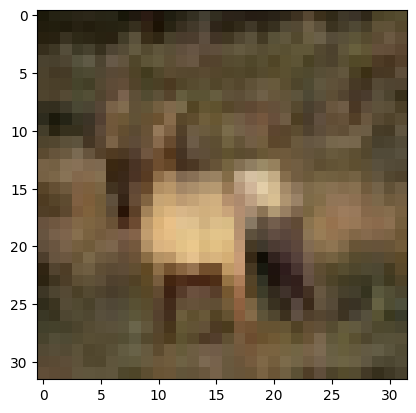

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 3

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [10]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [12]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                     tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])


In [13]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3171 - loss: 1.8904
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3840 - loss: 1.7140
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4081 - loss: 1.6471
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4242 - loss: 1.6044
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4333 - loss: 1.5777
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4435 - loss: 1.5556
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4467 - loss: 1.5395
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4555 - loss: 1.5233
Epoch 9/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4603 - loss: 1.5085
Epoch 10/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4620 - loss: 1.4978
Epoch 11/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4669 - loss: 1.4847
Epoch 12/100
1563/1

In [14]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4668 - loss: 1.5140


[1.5140467882156372, 0.4668000042438507]

In [15]:
classifications = model.predict(test_images)

print(classifications[34])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.12703258 0.05452957 0.0174505  0.00452006 0.02517906 0.00217303 0.00150912 0.03893561 0.0369886  0.691682  ]


In [16]:
print(test_labels[3])

[0]


Saving plne.jpg to plne (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


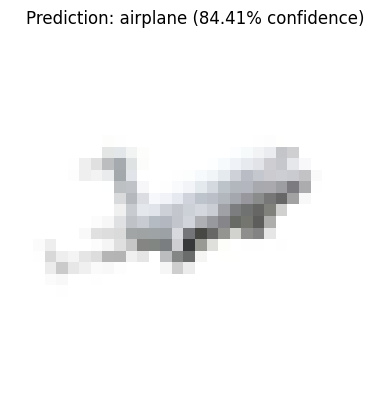

Uploaded file: plne (1).jpg
Predicted class number: 0
Predicted class name: airplane
Confidence: 84.41%

All class probabilities:
  airplane: 84.41%
  automobile: 0.24%
  bird: 6.75%
  cat: 2.09%
  deer: 1.59%
  dog: 1.78%
  frog: 0.69%
  horse: 0.90%
  ship: 1.38%
  truck: 0.17%


In [18]:
# Upload your own image and predict the cifar class
# Run this cell AFTER training the model.

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Upload an image file: png, jpg, jpeg, etc.
uploaded = files.upload()

for file_name in uploaded.keys():
    # 1. Open uploaded image and convert to RGB format (CIFAR-10 requires 3 color channels)
    img = Image.open(file_name).convert("RGB")

    # 2. Resize image to 32 x 32 because CIFAR-10 images are 32x32
    img_resized = img.resize((32, 32))

    # 3. Convert image into numpy array and normalize values from 0.0 to 1.0
    img_array = np.array(img_resized) / 255.0

    # 4. Add batch dimension: model expects shape (1, 32, 32, 3)
    img_input = np.expand_dims(img_array, axis=0)

    # 5. Predict
    prediction = model.predict(img_input)
    predicted_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    # 6. Show result (display original img or resized img_array)
    plt.imshow(img_array)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]} ({confidence:.2f}% confidence)")
    plt.show()

    print("Uploaded file:", file_name)
    print("Predicted class number:", predicted_index)
    print("Predicted class name:", class_names[predicted_index])
    print(f"Confidence: {confidence:.2f}%")
    print("\nAll class probabilities:")
    for name, prob in zip(class_names, prediction[0]):
        print(f"  {name}: {prob*100:.2f}%")


In [19]:
import gradio as gr
import numpy as np
from PIL import Image

# CIFAR-10 class names (Updated)
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

def predict_cifar_image(uploaded_image):
    """
    This function takes an uploaded image,
    preprocesses it like CIFAR-10,
    and predicts its class using the trained model.
    """
    # 1. Convert to RGB color format (CIFAR-10 requires 3 channels)
    img = uploaded_image.convert("RGB")

    # 2. Resize image to 32x32 because CIFAR-10 images are 32x32
    img = img.resize((32, 32))

    # 3. Convert image to numpy array
    img_array = np.array(img)

    # 4. Normalize pixel values from 0-255 to 0-1
    img_array = img_array / 255.0

    # 5. Add batch dimension: (32, 32, 3) becomes (1, 32, 32, 3)
    img_input = np.expand_dims(img_array, axis=0)

    # 6. Predict using trained model
    prediction = model.predict(img_input)

    # 7. Get predicted class index
    predicted_index = np.argmax(prediction)

    # 8. Get confidence percentage
    confidence = np.max(prediction) * 100

    # Create result text
    result = f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}%"

    # Return all class probabilities
    probabilities = {
        class_names[i]: float(prediction[0][i])
        for i in range(len(class_names))
    }

    return result, probabilities


# Create Gradio interface
demo = gr.Interface(
    fn=predict_cifar_image,
    inputs=gr.Image(type="pil", label="Upload CIFAR-10 Image"),
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Label(num_top_classes=10, label="Class Probabilities")
    ],
    title="CIFAR-10 Image Classifier",
    description="Upload an image of an airplane, automobile, bird, cat, deer, dog, frog, horse, ship, or truck. The model will predict its class."
)

# Launch app
demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6f9c0a18129ef5ab45.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
